# MNIST and CNN

## MNIST

### Load Dataset

In [1]:
import torchvision.datasets as dsets
import torchvision.transforms as transforms

In [2]:
train_data = dsets.MNIST(root='data/',
                         train=True,
                         transform=transforms.ToTensor(),
                         download=True)

test_data = dsets.MNIST(root='data/',
                        train=False,
                        transform=transforms.ToTensor(),
                        download=True)

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

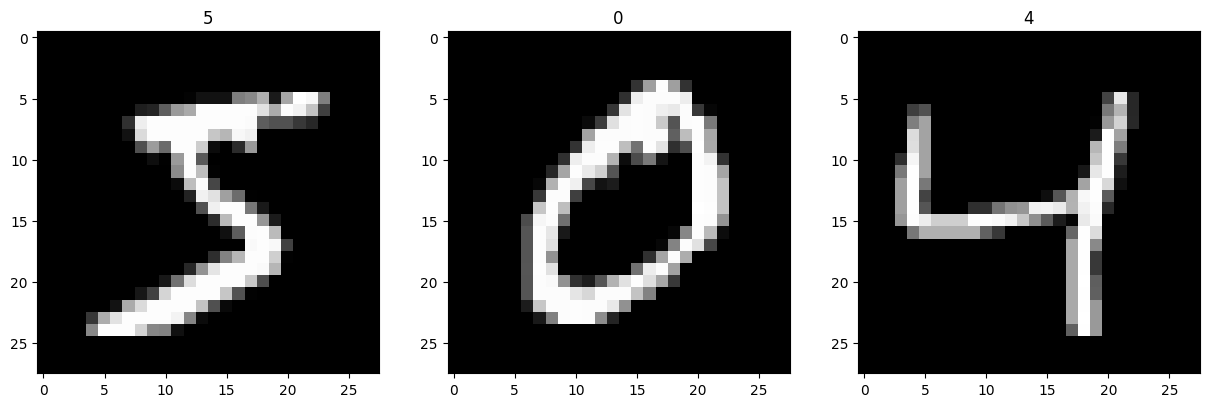

In [4]:
fig = plt.figure(figsize = (15, 5))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

ax1.set_title(train_data.targets[0].item())
ax1.imshow(train_data.data[0,:,:].numpy(), cmap='gray')

ax2.set_title(train_data.targets[1].item())
ax2.imshow(train_data.data[1,:,:].numpy(), cmap='gray')

ax3.set_title(train_data.targets[2].item())
ax3.imshow(train_data.data[2,:,:].numpy(), cmap='gray')

### Make Batches

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [6]:
batch_size = 100

train_loader = DataLoader(dataset=train_data,
                          batch_size=batch_size,
                          shuffle=True)

test_loader = DataLoader(dataset=test_data,
                         batch_size=batch_size,
                         shuffle=False)

In [7]:
batch_images, batch_labels = next(iter(train_loader))
print(batch_labels.numpy(), ", ", len(batch_labels.numpy()))

[5 6 2 1 1 4 4 9 0 8 6 0 7 3 4 9 7 9 2 7 1 9 1 2 4 5 0 0 2 2 0 4 8 6 4 6 3
 1 1 9 6 3 2 7 6 3 5 2 4 2 3 4 1 3 4 7 1 9 9 2 9 7 2 1 9 6 0 4 0 0 7 2 5 5
 0 2 6 0 7 7 2 9 5 1 2 3 8 3 5 4 0 2 5 5 5 5 9 7 7 4] ,  100


## Train & Evaluate MLP

### Train MLP

In [8]:
model = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Linear(512, 1000),
    nn.ReLU(),
    nn.Linear(1000, 10)
)

In [9]:
loss = nn.CrossEntropyLoss()
# def cross_entropy(input, target, weight=None, size_average=True, ignore_index=-100, reduce=True):

# Args:
#     input: Variable :math:`(N, C)` where `C = number of classes`
#     target: Variable :math:`(N)` where each value is
#         `0 <= targets[i] <= C-1`
#     weight (Tensor, optional): a manual rescaling weight given to each

In [10]:
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [11]:
num_epochs = 5

In [12]:
for epoch in range(num_epochs):
    
    total_batch = len(train_data) // batch_size
    
    for i, (batch_images, batch_labels) in enumerate(train_loader):
        
        x = batch_images.view(-1, 28 * 28)
        y = batch_labels
        
        pre = model(x)
        cost = loss(pre, y)
        
        optimizer.zero_grad()
        cost.backward()
        optimizer.step()
        
        if (i+1) % 300 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.4f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))
    
print("Learning Finished!")

Epoch [1/5], lter [300/600], Loss: 2.2892


Epoch [1/5], lter [600/600], Loss: 2.2674


Epoch [2/5], lter [300/600], Loss: 2.2497


Epoch [2/5], lter [600/600], Loss: 2.2326


Epoch [3/5], lter [300/600], Loss: 2.2047


Epoch [3/5], lter [600/600], Loss: 2.1934


Epoch [4/5], lter [300/600], Loss: 2.1458


Epoch [4/5], lter [600/600], Loss: 2.1211


Epoch [5/5], lter [300/600], Loss: 2.0379


Epoch [5/5], lter [600/600], Loss: 2.0201
Learning Finished!


### Evaluate MLP

In [13]:
correct = 0
total = 0

for images, labels in test_data:
    
    images  = images.view(-1, 28 * 28)
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += 1
    correct += (predicted == labels).sum()
    
print('Accuracy of test images: %f %%' % (100 * float(correct) / total))

Accuracy of test images: 69.140000 %


In [14]:
import random
r = random.randint(0, len(test_data)-1)
x_single = test_data.data[r:r + 1].view(-1,28*28).float()
y_single = test_data.targets[r:r + 1]

Label :  [0]
Prediction :  [0]


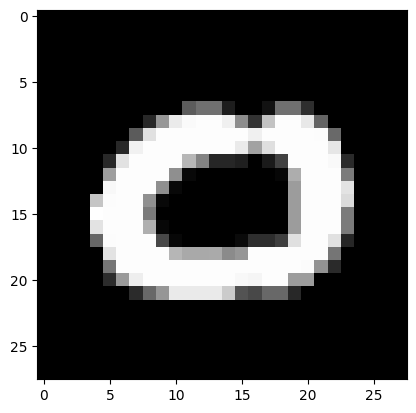

In [15]:
pre_single = model(x_single)
plt.imshow(x_single.data.view(28,28).numpy(), cmap='gray')

print('Label : ', y_single.data.view(1).numpy())
print('Prediction : ', torch.max(pre_single.data, 1)[1].numpy())

## Train & Evaluate CNN

### Train CNN

In [16]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 16, 5), # 1x28x28 -> 16x24x24
            nn.ReLU(),
            nn.Conv2d(16, 32, 5), # 16x24x24 -> 32x20x20
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 32x20x20 -> 
            nn.Conv2d(32, 64, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.fc_layer = nn.Sequential(
            nn.Linear(64*3*3, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )       
        
    def forward(self,x):
        out = self.conv_layer(x)
        out = out.view(-1,64*3*3)
        out = self.fc_layer(out)

        return out

In [17]:
model = CNN().cuda()

In [18]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [19]:
num_epochs = 3

In [20]:
for epoch in range(num_epochs):

    total_batch = len(train_data) // batch_size

    for i, (batch_images, batch_labels) in enumerate(train_loader):

        x = batch_images.cuda()
        y = batch_labels.cuda()

        pre = model(x)
        cost = loss(pre, y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 300 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.4f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/3], lter [300/600], Loss: 2.2554


Epoch [1/3], lter [600/600], Loss: 0.5677


Epoch [2/3], lter [300/600], Loss: 0.3461


Epoch [2/3], lter [600/600], Loss: 0.2247


Epoch [3/3], lter [300/600], Loss: 0.2213


Epoch [3/3], lter [600/600], Loss: 0.1139


### Evaulate CNN

In [21]:
correct = 0
total = 0

for images, labels in test_loader:
    
    images = images.cuda()
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()
    
print('Accuracy of test images: %f %%' % (100 * float(correct) / total))

Accuracy of test images: 96.210000 %


## Save and Load Model

### Save Model

In [22]:
torch.save(model, "sample1.pth")

In [23]:
torch.save(model.state_dict(), "sample2.pth")

### Load Model

In [24]:
# PyTorch 2.6+에서는 전체 객체 로딩 시 weights_only=False 필요
# In PyTorch 2.6+, whole-object loading requires weights_only=False
torch.load("sample1.pth", weights_only=False)

CNN(
  (conv_layer): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Linear(in_features=576, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [25]:
# 클래스가 변경/제거되면 무조건 에러 (전체 객체 저장 방식)
# Always errors if class changes/disappears (whole-object save)
del CNN
torch.load("sample1.pth")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.CNN was not an allowed global by default. Please use `torch.serialization.add_safe_globals([__main__.CNN])` or the `torch.serialization.safe_globals([__main__.CNN])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_o

In [26]:
# 클래스가 변경/제거되어도 불러올 수 있음 (state_dict 방식)
# Can be loaded even if the class changes/disappears (state_dict approach)
torch.load("sample2.pth", weights_only=True)

OrderedDict([('conv_layer.0.weight',
              tensor([[[[-7.6761e-02, -1.4730e-01, -1.8733e-02,  5.2152e-02,  1.6872e-01],
                        [ 4.0662e-02,  1.7794e-01,  1.9144e-01,  3.2289e-01,  2.2714e-01],
                        [ 1.9282e-01,  3.9890e-01,  3.1126e-01,  4.5217e-01,  1.8597e-01],
                        [ 2.7094e-01,  2.6928e-01,  1.3978e-01,  3.8875e-01,  1.1315e-01],
                        [ 1.5416e-01,  3.1552e-01,  1.7449e-01,  1.7597e-01,  2.1426e-01]]],
              
              
                      [[[ 1.9408e-01,  2.1135e-01,  1.5527e-01,  5.5545e-02, -1.2911e-01],
                        [-2.3606e-02,  2.1948e-01,  2.0866e-01,  2.3296e-01,  2.5508e-01],
                        [-4.3676e-02,  2.9888e-01,  3.1763e-01,  1.9904e-01,  1.8657e-01],
                        [ 5.0631e-03,  2.5406e-01,  2.9186e-02,  1.2694e-02,  1.1311e-01],
                        [ 4.5107e-02, -1.8302e-01, -1.5187e-01, -1.5451e-01,  7.8010e-02]]],
              
    

In [27]:
# 물론 최종적으로는 클래스 정의가 필요함
# Of course, the class definition is still required eventually
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 16, 5),
            nn.ReLU(),
            nn.Conv2d(16, 32, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(64*3*3, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )
        
    def forward(self, x):
        out = self.conv_layer(x)
        out = out.view(-1, 64*3*3)
        out = self.fc_layer(out)
        
        return out
    
model = CNN().cuda()
state = torch.load("sample2.pth", weights_only=True)
model.load_state_dict(state)

<All keys matched successfully>

In [28]:
model

CNN(
  (conv_layer): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Linear(in_features=576, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)

문제: $3 \times 3$ 입력에 대해 $2\times 2$ Conv (가중치=모두 1, bias 없음) → $2\times 2$ MaxPool → MSE 로 한 스텝 학습 (lr=0.5).
다음을 차례로 구하라:
- (#9) `pre.item()`
- (#10) `cost.item()`
- (#11) `model[0].weight.grad.sum().item()`  *(after `cost.backward()`)*
- (#12) `model[0].weight.data.sum().item()`  *(after `optimizer.step()`)*

Problem: train one step of a tiny CNN ($2\times 2$ Conv with all-ones weight, no bias → $2\times 2$ MaxPool → MSE, lr=0.5) on a single $3\times 3$ input. Find each of the values above.


In [29]:
import torch
import torch.nn as nn

x = torch.tensor([[[[1., 0., 2.],
                    [0., 3., 0.],
                    [2., 0., 1.]]]])
y = torch.tensor([[[[4.]]]])

model = nn.Sequential(
    nn.Conv2d(1, 1, 2, bias=False),
    nn.MaxPool2d(2, 2),
)
model[0].weight.data = torch.ones_like(model[0].weight.data)
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
loss = nn.MSELoss()

pre  = model(x)
cost = loss(pre, y)
print("pre.item()  =", pre.item())          # 5.0
print("cost.item() =", cost.item())         # 1.0

optimizer.zero_grad()
cost.backward()
print("weight.grad =\n", model[0].weight.grad)
print("weight.grad.sum() =", model[0].weight.grad.sum().item())   # 10.0

optimizer.step()
print("weight (after step) =\n", model[0].weight.data)
print("weight.sum() =", model[0].weight.data.sum().item())        # -1.0


pre.item()  = 5.0
cost.item() = 1.0
weight.grad =
 tensor([[[[0., 4.],
          [6., 0.]]]])
weight.grad.sum() = 10.0
weight (after step) =
 tensor([[[[ 1., -1.],
          [-2.,  1.]]]])
weight.sum() = -1.0


In [30]:
# AvgPool 변형 — 풀링만 nn.AvgPool2d 로 교체
# AvgPool variant — only the pool is replaced with nn.AvgPool2d
import torch
import torch.nn as nn

x = torch.tensor([[[[1., 0., 2.],
                    [0., 3., 0.],
                    [2., 0., 1.]]]])
y = torch.tensor([[[[4.]]]])

model = nn.Sequential(
    nn.Conv2d(1, 1, 2, bias=False),
    nn.AvgPool2d(2, 2),
)
model[0].weight.data = torch.ones_like(model[0].weight.data)
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
loss = nn.MSELoss()

pre  = model(x)
cost = loss(pre, y)
print("pre.item()  =", pre.item())          # 4.5
print("cost.item() =", cost.item())         # 0.25

optimizer.zero_grad()
cost.backward()
print("weight.grad =\n", model[0].weight.grad)
print("weight.grad.sum() =", model[0].weight.grad.sum().item())   # 4.5

optimizer.step()
print("weight (after step) =\n", model[0].weight.data)
print("weight.sum() =", model[0].weight.data.sum().item())        # 1.75


pre.item()  = 4.5
cost.item() = 0.25
weight.grad =
 tensor([[[[1.0000, 1.2500],
          [1.2500, 1.0000]]]])
weight.grad.sum() = 4.5
weight (after step) =
 tensor([[[[0.5000, 0.3750],
          [0.3750, 0.5000]]]])
weight.sum() = 1.75


MaxPool에서 최댓값 동률(tie)일 때 gradient 흐름 / Gradient flow when max values tie in MaxPool

In [ ]:
import torch
import torch.nn as nn

# 2x2 윈도우 내부가 모두 동일한 값(동률)
# All values in the 2x2 window are identical (tie)
x_tie = torch.tensor([[[[5., 5.],
                        [5., 5.]]]], requires_grad=True)

pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
out, idx = pool(x_tie)
print("pooled value:", out.item())
print("selected flat index in window:", idx.item())

# scalar로 만들어 backward
# Make scalar and run backward
out.sum().backward()
print("x_tie.grad =\n", x_tie.grad)

print("설명: gradient 1은 선택된 단 하나의 위치로만 전달됨. 같은 최대값인 경우 가장 처음 포지션.")
print("Note: gradient 1 is routed to only one selected (first) position.")

pooled value: 5.0
selected flat index in window: 0
x_tie.grad =
 tensor([[[[1., 0.],
          [0., 0.]]]])
설명: gradient 1은 선택된 단 하나의 위치로만 전달됨
Note: gradient 1 is routed to only one selected position
